# BigCloneBench Tuning Summary

Prints stored threshold/result rows for BCB Types 1-4 and the Type-3 similarity variants when present.


In [8]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "spectral_code").exists() and (candidate / "pipelines").exists():
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.utils.dataset_paths import output_root_for


TUNING_CONFIGS = [
    {"label": "Type 1", "clone_type": 1, "variant": "1", "slug": "bcb_type1"},
    {"label": "Type 2", "clone_type": 2, "variant": "2", "slug": "bcb_type2"},
    {"label": "Type 3 All", "clone_type": 3, "variant": "3/all", "slug": "bcb_type3_all"},
    {"label": "Type 3 Moderate", "clone_type": 3, "variant": "3/moderate", "slug": "bcb_type3_moderate"},
    {"label": "Type 3 Strong", "clone_type": 3, "variant": "3/strong", "slug": "bcb_type3_strong"},
    {"label": "Type 3 Very Strong", "clone_type": 3, "variant": "3/very_strong", "slug": "bcb_type3_very_strong"},
    {"label": "Type 4", "clone_type": 4, "variant": "4", "slug": "bcb_type4"},
]


def tuning_json_path(config: dict) -> Path:
    return output_root_for("bcb", config["variant"]) / f"trained_{config['slug']}_f1_pss_wasserstein.json"


def load_config_rows(config: dict) -> pd.DataFrame:
    path = tuning_json_path(config)
    base = {
        "label": config["label"],
        "clone_type": config["clone_type"],
        "variant": config["variant"],
        "source": str(path),
    }
    if not path.exists():
        return pd.DataFrame([{**base, "status": "missing tuning json"}])

    rows = json.loads(path.read_text(encoding="utf-8"))
    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame([{**base, "status": "empty tuning json"}])

    df.insert(0, "label", config["label"])
    df.insert(1, "clone_type", config["clone_type"])
    df.insert(2, "variant", config["variant"])
    df["source"] = str(path)
    df["status"] = "recorded"
    if "decision_threshold" not in df.columns and "best_threshold" in df.columns:
        df["decision_threshold"] = df["best_threshold"].astype(float).map(lambda value: float(np.nextafter(value, -np.inf)))
    return df


all_rows = pd.concat([load_config_rows(config) for config in TUNING_CONFIGS], ignore_index=True)
print("Loaded BCB tuning summaries")
display(all_rows)


Loaded BCB tuning summaries


,label,clone_type,variant,optimized_for,best_metric,graph_type,k_eigen,metric,metric_parameters,best_threshold,...,full_train_precision,full_train_recall,full_train_f1,full_train_auc,balanced_fold_metrics,score_time_seconds,threshold_time_seconds,total_config_time_seconds,source,status
0,Type 1,1,1,f1,1.000000,ast,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,1.000000,1.000000,1.000000,1.000000,"[{'accuracy': 1.0, 'precision': 1.0, 'recall':...",3.937863,0.195975,4.550355,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded
1,Type 1,1,1,f1,0.998933,cfg,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,0.997868,1.000000,0.998933,0.998527,"[{'accuracy': 0.9989318335404268, 'precision':...",4.071974,0.178350,4.660045,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded
2,Type 1,1,1,f1,1.000000,ddg,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,1.000000,1.000000,1.000000,1.000000,"[{'accuracy': 1.0, 'precision': 1.0, 'recall':...",3.899529,0.191662,4.549034,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded
3,Type 1,1,1,f1,1.000000,pdg,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,1.000000,1.000000,1.000000,1.000000,"[{'accuracy': 1.0, 'precision': 1.0, 'recall':...",3.788884,0.183734,4.397698,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded
4,Type 1,1,1,f1,1.000000,cpg,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,1.000000,1.000000,1.000000,1.000000,"[{'accuracy': 1.0, 'precision': 1.0, 'recall':...",4.181663,0.170995,4.796738,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded
5,Type 2,2,2,f1,1.000000,ast,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,1.000000,1.000000,1.000000,1.000000,"[{'accuracy': 1.0, 'precision': 1.0, 'recall':...",0.355563,0.031493,0.430451,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded
6,Type 2,2,2,f1,0.998905,cfg,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,0.997813,1.000000,0.998905,0.998162,"[{'accuracy': 0.9989040428641013, 'precision':...",0.316715,0.026982,0.388625,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded
7,Type 2,2,2,f1,1.000000,ddg,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,1.000000,1.000000,1.000000,1.000000,"[{'accuracy': 1.0, 'precision': 1.0, 'recall':...",0.435729,0.030506,0.506239,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded
8,Type 2,2,2,f1,1.000000,pdg,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,1.000000,1.000000,1.000000,1.000000,"[{'accuracy': 1.0, 'precision': 1.0, 'recall':...",0.300669,0.025513,0.366707,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded
9,Type 2,2,2,f1,1.000000,cpg,None,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",1.000000,...,1.000000,1.000000,1.000000,1.000000,"[{'accuracy': 1.0, 'precision': 1.0, 'recall':...",0.372892,0.026848,0.452706,C:\Users\koush\PyProjects\spectrals\outputs\bc...,recorded


In [9]:
metric_cols = ["train_accuracy", "train_precision", "train_recall", "train_f1", "train_auc", "best_metric"]
available_metric_cols = [col for col in metric_cols if col in all_rows.columns]
sort_cols = [col for col in ["train_f1", "train_auc", "train_accuracy", "best_metric"] if col in all_rows.columns]

recorded = all_rows[all_rows["status"] == "recorded"].copy()
if recorded.empty:
    print("No recorded tuning rows found yet.")
else:
    best_rows = []
    for variant, group in recorded.groupby("variant"):
        group = group.sort_values(sort_cols, ascending=[False] * len(sort_cols)) if sort_cols else group
        best_rows.append(group.iloc[0])
    best_df = pd.DataFrame(best_rows).reset_index(drop=True)
    columns = [
        "label", "clone_type", "variant", "graph_type", "metric", "k_eigen", "best_threshold", "decision_threshold",
        *available_metric_cols, "train_f1_variance", "train_auc_variance", "balanced_folds", "balanced_evaluation_enabled",
        "valid_pairs", "positive_pairs", "negative_pairs", "dropped_pairs", "status", "source",
    ]
    columns = [col for col in columns if col in best_df.columns]
    print("Best stored result per BCB config")
    display(best_df[columns])


Best stored result per BCB config


,label,clone_type,variant,graph_type,metric,k_eigen,best_threshold,decision_threshold,train_accuracy,train_precision,...,train_f1_variance,train_auc_variance,balanced_folds,balanced_evaluation_enabled,valid_pairs,positive_pairs,negative_pairs,dropped_pairs,status,source
0,Type 1,1,1,ast,pss,None,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,1,True,91746,45873,45873,0,recorded,C:\Users\koush\PyProjects\spectrals\outputs\bc...
1,Type 2,2,2,ast,pss,None,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,1,True,8212,4106,4106,0,recorded,C:\Users\koush\PyProjects\spectrals\outputs\bc...
2,Type 3 All,3,3/all,ast,pss,None,0.978392,0.978392,0.811207,0.766223,...,0.0,0.0,1,True,211930,105965,105965,0,recorded,C:\Users\koush\PyProjects\spectrals\outputs\bc...
3,Type 3 Moderate,3,3/moderate,ast,pss,None,0.609325,0.609325,0.795382,0.744136,...,0.0,0.0,1,True,172082,86041,86041,0,recorded,C:\Users\koush\PyProjects\spectrals\outputs\bc...
4,Type 3 Strong,3,3/strong,ast,pss,None,0.736390,0.736390,0.918521,0.919324,...,0.0,0.0,1,True,33432,16716,16716,0,recorded,C:\Users\koush\PyProjects\spectrals\outputs\bc...
5,Type 3 Very Strong,3,3/very_strong,ast,pss,None,0.810963,0.810963,0.989557,0.986977,...,0.0,0.0,1,True,6416,3208,3208,0,recorded,C:\Users\koush\PyProjects\spectrals\outputs\bc...
6,Type 4,4,4,ast,pss,None,0.437248,0.437248,0.655720,0.601385,...,0.0,0.0,1,True,1878872,939436,939436,0,recorded,C:\Users\koush\PyProjects\spectrals\outputs\bc...


In [10]:
columns = [
    "label", "clone_type", "variant", "graph_type", "metric", "k_eigen", "best_threshold", "decision_threshold",
    "train_accuracy", "train_precision", "train_recall", "train_f1", "train_auc", "best_metric",
    "train_f1_variance", "train_auc_variance", "balanced_folds", "balanced_evaluation_enabled",
    "valid_pairs", "positive_pairs", "negative_pairs", "dropped_pairs", "status",
]
columns = [col for col in columns if col in all_rows.columns]
sort_cols = [col for col in ["clone_type", "variant", "train_f1", "train_auc", "train_accuracy", "graph_type", "metric"] if col in all_rows.columns]
ascending = [True, True, False, False, False, True, True][:len(sort_cols)]
print("All stored threshold/result rows")
display(all_rows[columns].sort_values(sort_cols, ascending=ascending) if sort_cols else all_rows[columns])


All stored threshold/result rows


,label,clone_type,variant,graph_type,metric,k_eigen,best_threshold,decision_threshold,train_accuracy,train_precision,...,best_metric,train_f1_variance,train_auc_variance,balanced_folds,balanced_evaluation_enabled,valid_pairs,positive_pairs,negative_pairs,dropped_pairs,status
0,Type 1,1,1,ast,pss,None,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000e+00,0.000000,1,True,91746,45873,45873,0,recorded
4,Type 1,1,1,cpg,pss,None,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000e+00,0.000000,1,True,91746,45873,45873,0,recorded
2,Type 1,1,1,ddg,pss,None,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000e+00,0.000000,2,True,91743,45873,45870,3,recorded
3,Type 1,1,1,pdg,pss,None,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000e+00,0.000000,1,True,91746,45873,45873,0,recorded
1,Type 1,1,1,cfg,pss,None,1.000000,1.000000,0.998932,0.997868,...,0.998933,0.000000e+00,0.000000,1,True,91746,45873,45873,0,recorded
5,Type 2,2,2,ast,pss,None,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000e+00,0.000000,1,True,8212,4106,4106,0,recorded
9,Type 2,2,2,cpg,pss,None,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000e+00,0.000000,1,True,8212,4106,4106,0,recorded
7,Type 2,2,2,ddg,pss,None,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000e+00,0.000000,2,True,8211,4106,4105,1,recorded
8,Type 2,2,2,pdg,pss,None,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000e+00,0.000000,1,True,8212,4106,4106,0,recorded
6,Type 2,2,2,cfg,pss,None,1.000000,1.000000,0.998904,0.997813,...,0.998905,0.000000e+00,0.000000,1,True,8212,4106,4106,0,recorded


## Final Summary Image Table


,Type,Graph,Metric,k,Clone pairs,Non-clone pairs,Accuracy,Precision,Recall,F1,AUC,Best graph
0,Type 1,AST,pss,full,45873,45873,1.000000,1.000000,1.000000,1.000000,1.000000,True
1,Type 1,CFG,pss,full,45873,45873,0.998932,0.997868,1.000000,0.998933,0.998527,False
2,Type 1,DDG,pss,full,45873,45870,1.000000,1.000000,1.000000,1.000000,1.000000,False
3,Type 1,PDG,pss,full,45873,45873,1.000000,1.000000,1.000000,1.000000,1.000000,False
4,Type 1,CPG,pss,full,45873,45873,1.000000,1.000000,1.000000,1.000000,1.000000,False
5,Type 2,AST,pss,full,4106,4106,1.000000,1.000000,1.000000,1.000000,1.000000,True
6,Type 2,CFG,pss,full,4106,4106,0.998904,0.997813,1.000000,0.998905,0.998162,False
7,Type 2,DDG,pss,full,4106,4105,1.000000,1.000000,1.000000,1.000000,1.000000,False
8,Type 2,PDG,pss,full,4106,4106,1.000000,1.000000,1.000000,1.000000,1.000000,False
9,Type 2,CPG,pss,full,4106,4106,1.000000,1.000000,1.000000,1.000000,1.000000,False


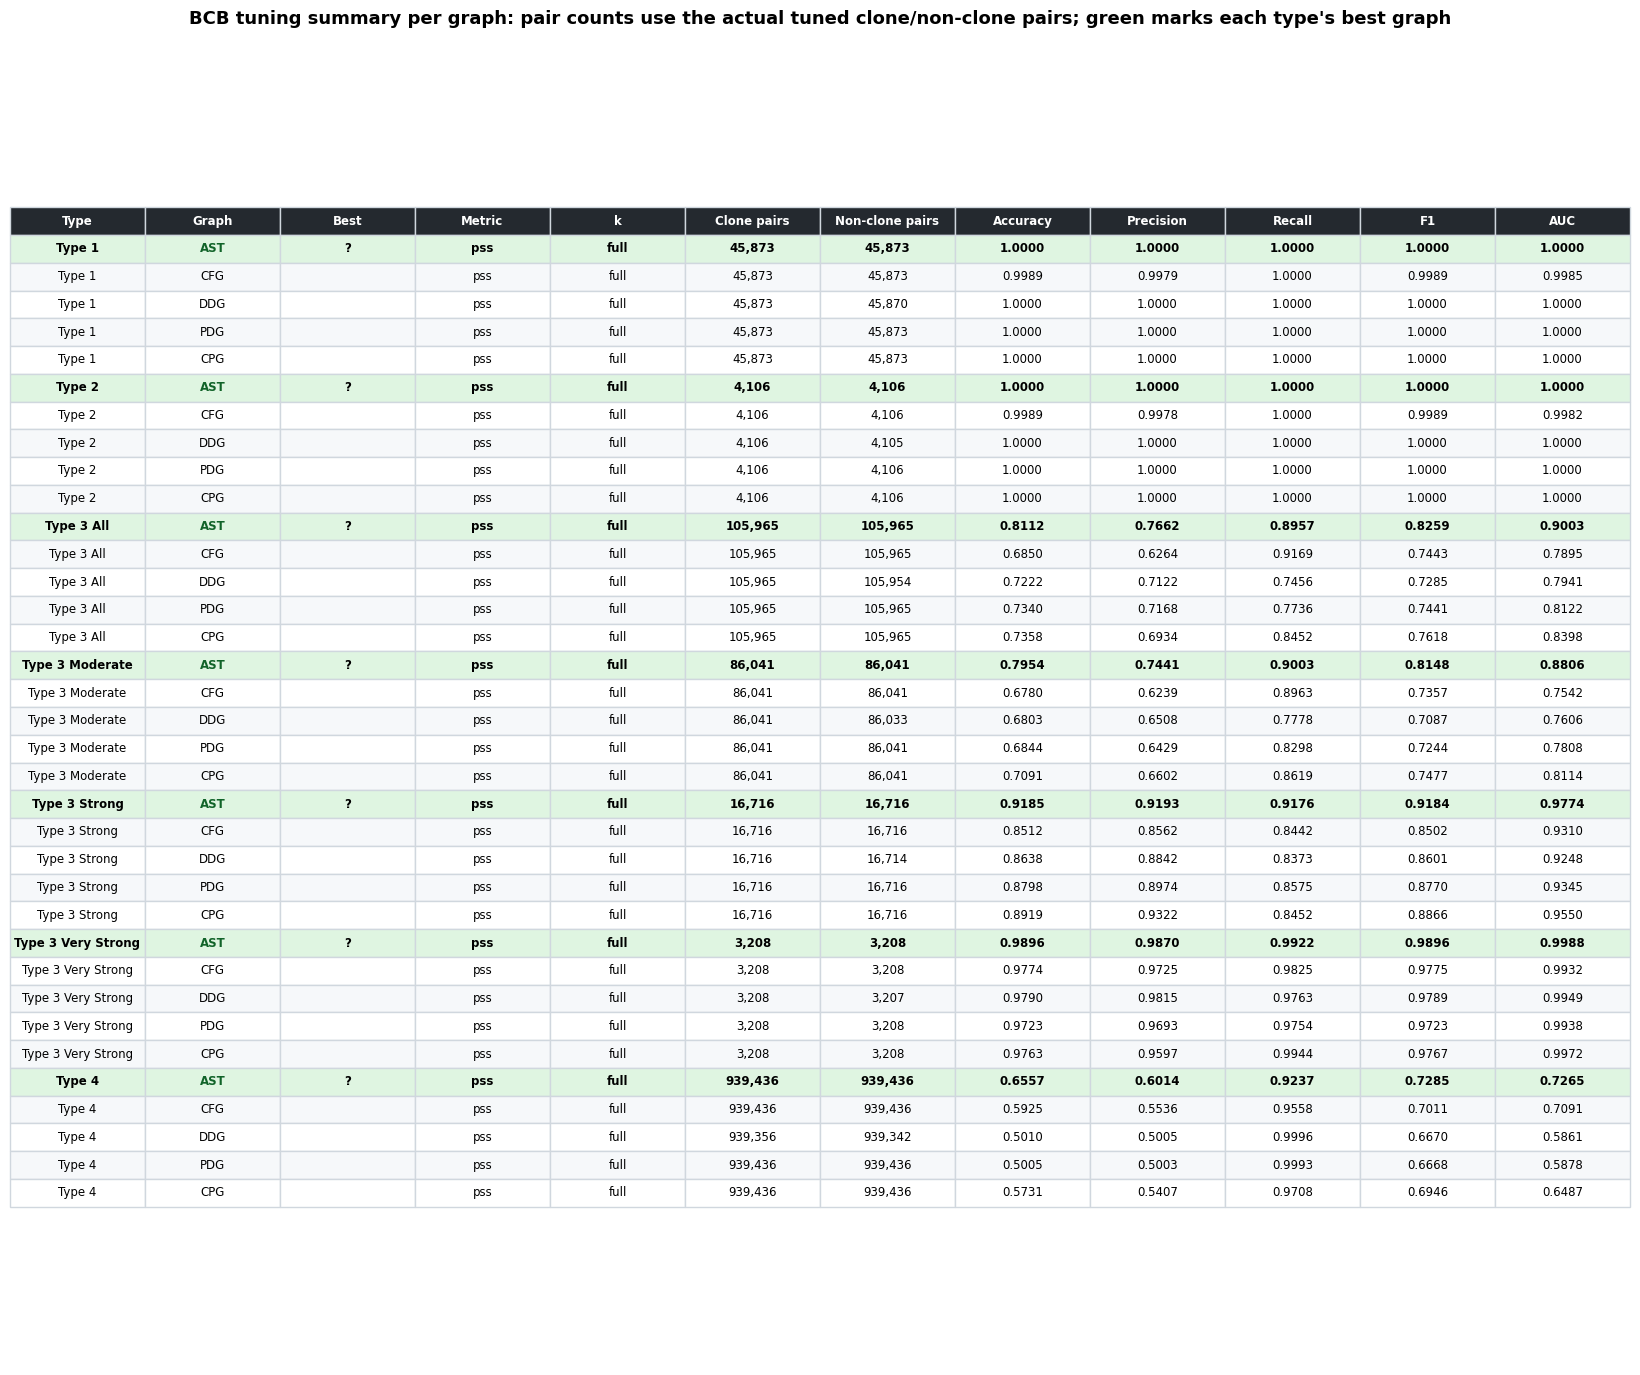

In [11]:
import matplotlib.pyplot as plt

GRAPH_ORDER = ["ast", "cfg", "ddg", "pdg", "cpg"]
RANK_COLS = ["train_accuracy", "train_f1", "train_auc"]


def pick_best_row(df: pd.DataFrame) -> pd.Series:
    rank_cols = [col for col in RANK_COLS if col in df.columns]
    if not rank_cols:
        return df.iloc[0]
    return df.sort_values(rank_cols, ascending=[False] * len(rank_cols)).iloc[0]


summary_rows = []
recorded_rows = all_rows[all_rows.get("status", "").astype(str).eq("recorded")].copy() if "status" in all_rows.columns else all_rows.copy()

for config in TUNING_CONFIGS:
    type_rows = recorded_rows[recorded_rows["variant"].astype(str).eq(str(config["variant"]))].copy()
    if type_rows.empty or "graph_type" not in type_rows.columns:
        summary_rows.append({
            "Type": config["label"],
            "Graph": "-",
            "Metric": "-",
            "k": "-",
            "Clone pairs": np.nan,
            "Non-clone pairs": np.nan,
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "F1": np.nan,
            "AUC": np.nan,
            "Best graph": False,
        })
        continue

    graph_rows = []
    available_graphs = [graph for graph in GRAPH_ORDER if graph in set(type_rows["graph_type"].astype(str))]
    available_graphs.extend(sorted(set(type_rows["graph_type"].astype(str)) - set(available_graphs)))

    for graph_type in available_graphs:
        graph_df = type_rows[type_rows["graph_type"].astype(str).eq(graph_type)].copy()
        if graph_df.empty:
            continue
        best = pick_best_row(graph_df)
        row = {
            "Type": config["label"],
            "Graph": str(best.get("graph_type", graph_type)).upper(),
            "Metric": str(best.get("metric", "-")),
            "k": "full" if pd.isna(best.get("k_eigen", "full")) else str(best.get("k_eigen", "full")),
            "Clone pairs": int(best.get("positive_pairs", 0)) if pd.notna(best.get("positive_pairs", np.nan)) else np.nan,
            "Non-clone pairs": int(best.get("negative_pairs", 0)) if pd.notna(best.get("negative_pairs", np.nan)) else np.nan,
            "Accuracy": float(best.get("train_accuracy", np.nan)),
            "Precision": float(best.get("train_precision", np.nan)),
            "Recall": float(best.get("train_recall", np.nan)),
            "F1": float(best.get("train_f1", np.nan)),
            "AUC": float(best.get("train_auc", np.nan)),
            "Best graph": False,
        }
        graph_rows.append(row)

    if graph_rows:
        graph_summary_df = pd.DataFrame(graph_rows)
        best_idx = graph_summary_df.sort_values(["Accuracy", "F1", "AUC"], ascending=[False, False, False]).index[0]
        graph_summary_df.loc[best_idx, "Best graph"] = True
        summary_rows.extend(graph_summary_df.to_dict("records"))

final_summary_df = pd.DataFrame(summary_rows)
display(final_summary_df)

plot_df = final_summary_df.copy()
best_mask = plot_df["Best graph"].astype(bool).to_numpy() if "Best graph" in plot_df.columns else np.zeros(len(plot_df), dtype=bool)
plot_df["Best"] = np.where(best_mask, "?", "")
plot_df = plot_df[["Type", "Graph", "Best", "Metric", "k", "Clone pairs", "Non-clone pairs", "Accuracy", "Precision", "Recall", "F1", "AUC"]]

for col in ["Clone pairs", "Non-clone pairs"]:
    plot_df[col] = plot_df[col].map(lambda value: f"{int(value):,}" if pd.notna(value) else "-")
for col in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    plot_df[col] = plot_df[col].map(lambda value: f"{float(value):.4f}" if pd.notna(value) else "-")

fig_height = max(4.5, 0.35 * len(plot_df) + 1.6)
fig, ax = plt.subplots(figsize=(16.5, fig_height))
ax.axis("off")
table = ax.table(
    cellText=plot_df.values,
    colLabels=plot_df.columns,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.0, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D7DE")
    if row == 0:
        cell.set_facecolor("#24292F")
        cell.get_text().set_color("white")
        cell.get_text().set_weight("bold")
        continue

    is_best = bool(best_mask[row - 1]) if row - 1 < len(best_mask) else False
    if is_best:
        cell.set_facecolor("#DFF5E1")
        cell.get_text().set_weight("bold")
        if col == 1:
            cell.get_text().set_color("#116329")
    elif row % 2 == 0:
        cell.set_facecolor("#F6F8FA")
    else:
        cell.set_facecolor("white")

ax.set_title(
    "BCB tuning summary per graph: pair counts use the actual tuned clone/non-clone pairs; green marks each type's best graph",
    fontsize=13,
    weight="bold",
    pad=18,
)
plt.tight_layout()
plt.show()
